# EDA - Brain Tumor MRI Dataset
Exploratory analysis: class distribution, image sizes, sample images, pixel intensity.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

from src.data.clean import scan_dataset
from src.utils.config import load_config

sns.set_theme(style='whitegrid')
cfg = load_config()
df = scan_dataset(cfg.paths.raw_data, cfg.data.classes)
print(f'Total images: {len(df)}')
df.head()

Total images: 7200


,filepath,label,source_split
0,D:\Project\Brain_tumor\data\raw\Testing\glioma...,glioma,testing
1,D:\Project\Brain_tumor\data\raw\Testing\glioma...,glioma,testing
2,D:\Project\Brain_tumor\data\raw\Testing\glioma...,glioma,testing
3,D:\Project\Brain_tumor\data\raw\Testing\glioma...,glioma,testing
4,D:\Project\Brain_tumor\data\raw\Testing\glioma...,glioma,testing


## Class distribution

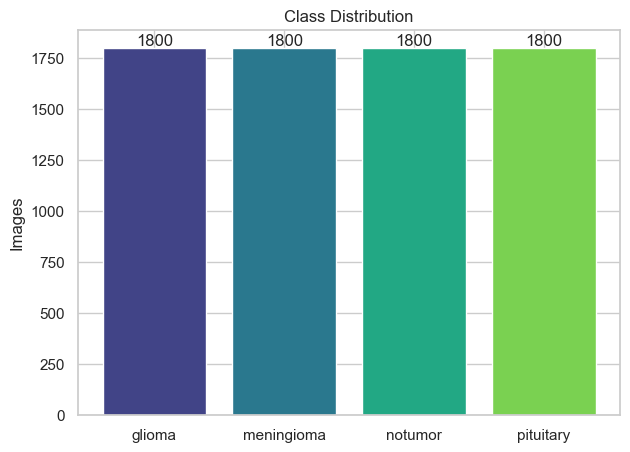

label
glioma        1800
meningioma    1800
notumor       1800
pituitary     1800
Name: count, dtype: int64

In [2]:
counts = df['label'].value_counts().reindex(cfg.data.classes)
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(counts.index, counts.values, color=sns.color_palette('viridis', 4))
ax.bar_label(bars)
ax.set_title('Class Distribution'); ax.set_ylabel('Images')
plt.show()
counts

## Image dimensions

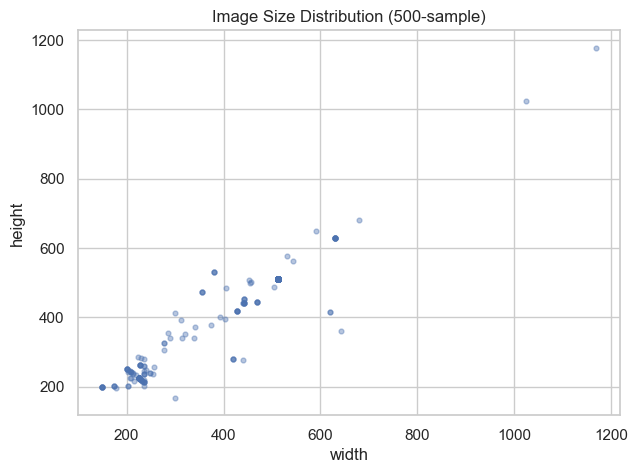

,width,height
count,500.000000,500.000000
mean,457.710000,460.216000
std,122.266742,117.790401
min,150.000000,168.000000
25%,455.750000,474.000000
50%,512.000000,512.000000
75%,512.000000,512.000000
max,1168.000000,1178.000000


In [3]:
sizes = df['filepath'].sample(min(500, len(df)), random_state=cfg.project.seed).apply(lambda fp: Image.open(fp).size)
size_df = pd.DataFrame(sizes.tolist(), columns=['width', 'height'])
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(size_df['width'], size_df['height'], alpha=0.4, s=12)
ax.set_title('Image Size Distribution (500-sample)'); ax.set_xlabel('width'); ax.set_ylabel('height')
plt.show()
size_df.describe()

## Sample images per class

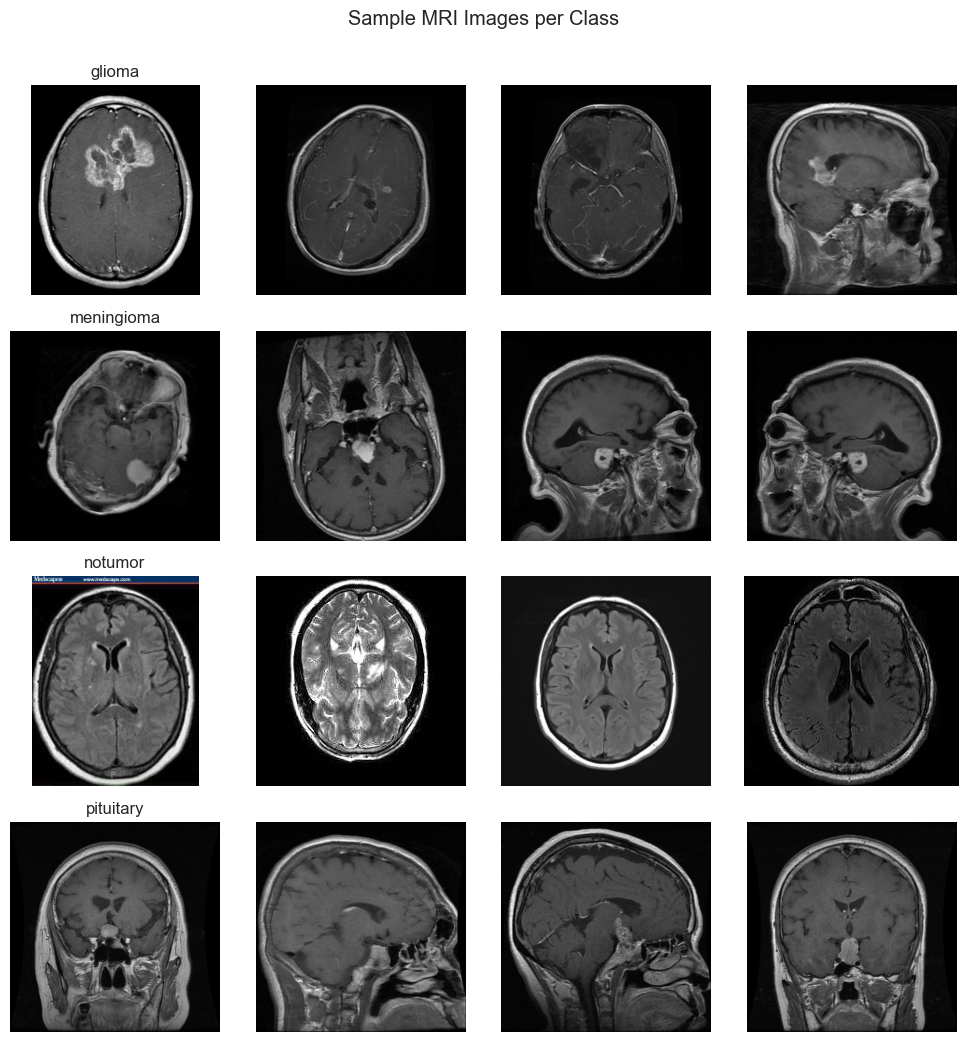

In [4]:
fig, axes = plt.subplots(len(cfg.data.classes), 4, figsize=(10, 2.6 * len(cfg.data.classes)))
for i, cls in enumerate(cfg.data.classes):
    for j, fp in enumerate(df[df['label'] == cls]['filepath'].head(4)):
        axes[i, j].imshow(Image.open(fp), cmap='gray')
        axes[i, j].axis('off')
        axes[i, j].set_title(cls if j == 0 else '')
fig.suptitle('Sample MRI Images per Class', y=1.0)
fig.tight_layout()
plt.show()

## Pixel intensity distribution

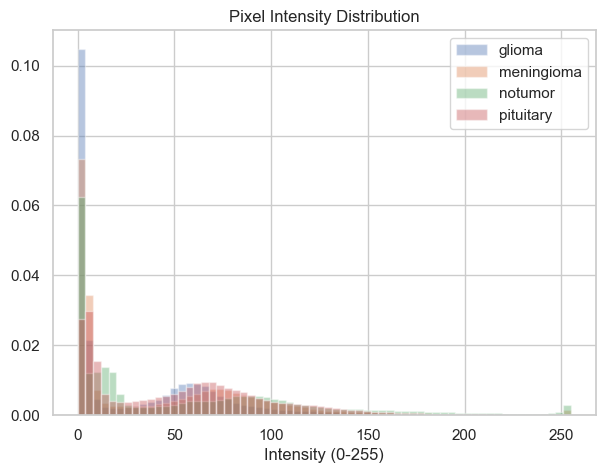

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for cls in cfg.data.classes:
    pixels = []
    for fp in df[df['label'] == cls]['filepath'].sample(min(75, len(df[df['label'] == cls])), random_state=cfg.project.seed):
        pixels.append(np.asarray(Image.open(fp).convert('L')).ravel())
    ax.hist(np.concatenate(pixels), bins=64, alpha=0.4, label=cls, density=True)
ax.set_title('Pixel Intensity Distribution'); ax.set_xlabel('Intensity (0-255)'); ax.legend()
plt.show()